In [ ]:
import os

if not os.path.exists('DS_MLProject_ColabIntegration'):
  !git clone https://github.com/ns15468-gasou/DS_ML_Project_ColabIntegration.git
os.chdir('DS_ML_Project_ColabIntegration/Project/notebooks')
print("Working directory", os.getcwd())

Cloning into 'DS_ML_Project_ColabIntegration'...
remote: Enumerating objects: 472, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 472 (delta 45), reused 49 (delta 20), pack-reused 378 (from 2)
Receiving objects: 100% (472/472), 53.90 MiB | 35.93 MiB/s, done.
Resolving deltas: 100% (231/231), done.
Working directory /content/DS_ML_Project_ColabIntegration/Project/notebooks


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
from urllib.parse import urlparse


In [ ]:
phish = pd.read_csv('../data/processed_input/phishtank_cleaned.csv')

other = phish[phish['target']=='Other'].copy()
print(f"total Phishtank rows: {len(phish)}")
print(f"'Other' rows: {len(other)}")
other.head()

total Phishtank rows: 56045
'Other' rows: 52773


,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9358496,https://sgpass-fr033.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:49+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
1,9358495,https://sgpass-fr033.com/pages/asset.php,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:36+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
2,9358485,https://dervi-emprend-ec.webcindario.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:27:05+00:00,yes,2026-03-03T19:32:43+00:00,yes,Other
6,9358476,https://passage-route-mobilites.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:16:14+00:00,yes,2026-03-03T19:22:49+00:00,yes,Other
7,9358475,https://www.passage-route-mobilites.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:16:04+00:00,yes,2026-03-03T19:22:49+00:00,yes,Other


In [ ]:


phish['host'] = phish['url'].apply(lambda x: urlparse(x).netloc.lower())
phish['full_length'] = phish['url'].str.len()
phish['host_length'] = phish['host'].str.len()
phish['path'] = phish['url'].apply(lambda x: urlparse(x).path)
phish['path_depth'] = phish['path'].apply(lambda p:
p.strip('/').count('/') + 1 if p.strip('/') else 0)
phish['dot_count'] = phish['url'].str.count(r'\.')
phish['hyphen_count'] = phish['url'].str.count('-')
phish['digit_count'] = phish['url'].str.count(r'\d')
phish['digit_ratio'] = phish['digit_count'] / phish['full_length']
phish['subdomain_depth'] = phish['host'].str.count(r'\.')

other = phish[phish['target'] == 'Other'].copy()
print(other.shape)


(52773, 18)


In [ ]:
features = ['host_length', 'path_depth', 'dot_count', 'hyphen_count', 'digit_ratio', 'subdomain_depth']

X = other[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")

Feature matrix shape: (52773, 6)


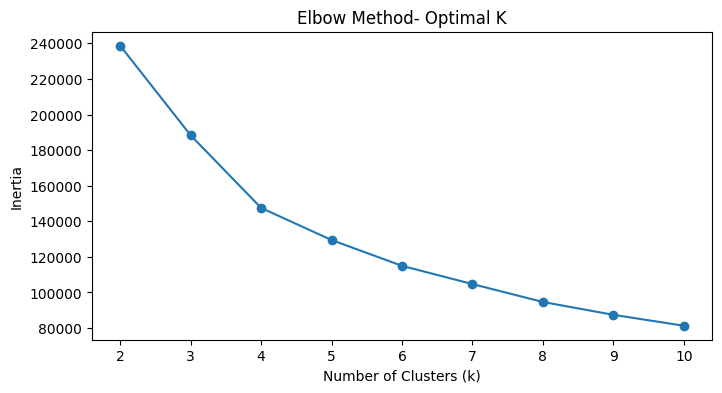

In [ ]:
inertia = []
k_range = range(2,11)

for k in k_range:
  km = KMeans(n_clusters=k, random_state=777, n_init=10)
  km.fit(X_scaled)
  inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method- Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout
plt.show()


# Note
Seeing as the curve is nearly linear, there does not exist an extremely obvious choice for number of clusters. That said, the most drastic point of change in derivative is at k=4.

In [ ]:
km = KMeans(n_clusters=4, random_state=777, n_init=10)
other['cluster'] = km.fit_predict(X_scaled)

print(other['cluster'].value_counts())

cluster
1    21341
3    15517
2     8680
0     7235
Name: count, dtype: int64


In [ ]:
cluster_summary = other.groupby('cluster')[features].mean().round(2)
print(cluster_summary)

         host_length  path_depth  dot_count  hyphen_count  digit_ratio  \
cluster                                                                  
0              38.65        0.59       2.82          1.09         0.24   
1              21.29        0.67       2.15          0.44         0.03   
2              15.88        4.51       2.40          2.11         0.10   
3               8.75        1.07       1.07          0.34         0.04   

         subdomain_depth  
cluster                   
0                   2.27  
1                   2.07  
2                   1.99  
3                   1.00  


In [21]:
for c in range(4):
  print(f"\n--- Cluster {c} ---")
  print(other[other['cluster']== c]['url'].sample(5, random_state=777).values)


--- Cluster 0 ---
['https://pub-7497b4cc97ab46a6a9a492eb1b6a38ec.r2.dev/index.html'
 'https://eu.jotform.com/app/251023382704347'
 'https://eu.jotform.com/app/251953383222355'
 'http://full-language-233771.framer.app'
 'https://soulful-time-409544.framer.app/']

--- Cluster 1 ---
['https://sites.google.com/view/oiuiruieor98490krejjkljklejkef/home'
 'https://webkkwel.weebly.com/' 'https://adminhelpdeskunit1.weebly.com/'
 'https://reppliesemail80.wixsite.com/my-site-8'
 'https://id-ionos-de-webmail-system.blogspot.com/']

--- Cluster 2 ---
['https://docs.google.com/presentation/d/e/2PACX-1vS96MJlExf8-vB6o92_y3280HOorS1tEIuLw2kLOWBa6bCQv0MoIc6IoE1n_FWoGfdfzwE5s4ePEpU-/pub?start=false&amp;loop=false&amp;delayms=3000'
 'https://docs.google.com/presentation/d/e/2PACX-1vSOoUtP07QkeL37KsIa_8kJZYi2tZuHhSDsX5uiNK46ZnL2qe6Kf6gJkXGMhSrO3vN2N8CBf4QSSTxb/pub?start=false&amp;loop=false&amp;delayms=3000'
 'https://www.dropbox.com/scl/fi/rqwa7nyayqn676cdeav2d/BT-VOICE.paper?dl=0&oref=e&r=ACOESsI_Du8Ld

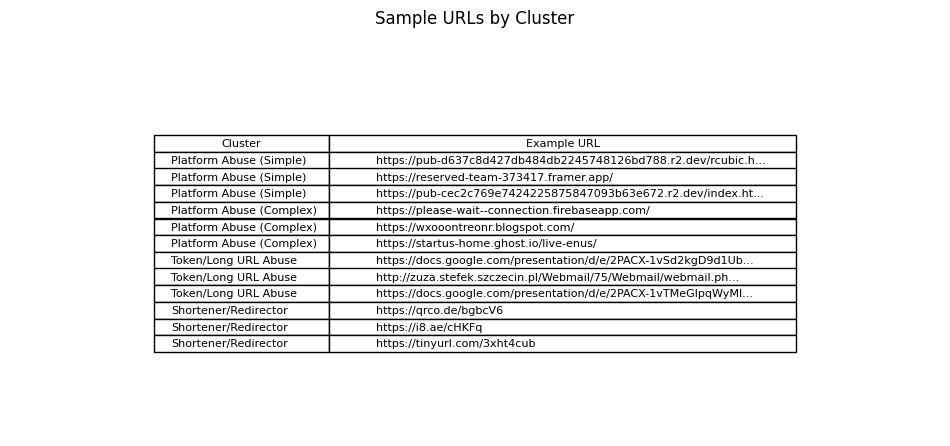

In [26]:
samples = []
for c in range(4):
      label = cluster_names[c]
      urls = other[other['cluster'] == c]['url'].sample(3,
  random_state=42).values
      for url in urls:
          samples.append({'Cluster': label, 'Example URL': url[:60] +
  '...' if len(url) > 60 else url})

sample_df = pd.DataFrame(samples)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')
table = ax.table(cellText=sample_df.values, colLabels=sample_df.columns,

                   loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(sample_df.columns))))
plt.title('Sample URLs by Cluster', pad=20)
fig.patch.set_visible(False)
plt.savefig('cluster_samples.png', dpi=150, bbox_inches='tight',
transparent=True)
plt.show()

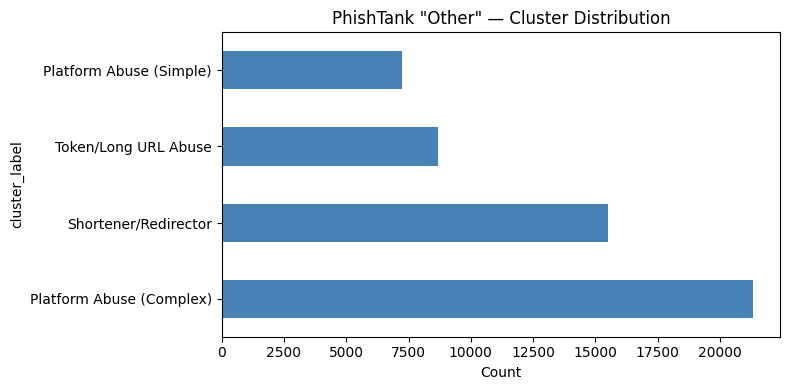

In [ ]:
cluster_names = {0: 'Platform Abuse (Simple)',
                 1: 'Platform Abuse (Complex)',
                 2: 'Token/Long URL Abuse', 3: 'Shortener/Redirector'}

other['cluster_label'] = other['cluster'].map(cluster_names)
other['cluster_label'].value_counts().plot(kind='barh', figsize=(8,4),
                                            color='steelblue')
plt.title('PhishTank "Other" — Cluster Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.show()